# Transient heat equation on hex mesh
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/solid/thermal_transient.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/solid/thermal_transient.ipynb)

Solving the transient heat eqaution on a hexahedron mesh.

In [1]:
import meshio as mo
import pyvista as pv
import torch

from torchfem import SolidHeat
from torchfem.data import get_data
from torchfem.materials import IsotropicConductivity3D
from torchfem.plot_utils import embed_pyvista_animation

# Set default data type to double precision
torch.set_default_dtype(torch.float64)

## 3D unstructured mesh with linear hexahedrons read from Abaqus input file 


In [2]:
kappa, rho, cp = 500.0, 7850.0, 500.0

In [3]:
inp_path = get_data("extruded_hex_mesh.inp")


# material
material = IsotropicConductivity3D(kappa=kappa, rho=rho * cp)


mesh = mo.read(inp_path)
# Create model
nodes = torch.tensor(mesh.points) * 1.0e-3  # SI
elements = torch.tensor(mesh.cells_dict["hexahedron"])
box_heat = SolidHeat(nodes, elements, material)


# Assign boundary conditions
box_heat.constraints[mesh.point_sets["temp_left"]] = True
box_heat.constraints[mesh.point_sets["temp_right"]] = True
# box_heat.constraints[mesh.point_sets["insulation"]] = True
box_heat.displacements[mesh.point_sets["temp_left"], 0] = 0.0
box_heat.displacements[mesh.point_sets["temp_right"], 0] = 20.0
# box_heat.forces[nodes[:, 1] == 1.0, 0] = 0.0
# box_heat.forces[mesh.point_sets["insulation"]] = 5.0

# solver settings
end_time = 5.0
delta_t = 0.2

# Results are returned at exactly these times
times = torch.arange(0.0, end_time + delta_t, delta_t)

# Solve
temp, rfl, hf, temp_grad, _ = box_heat.time_integration(times, delta_t, verbose=True)

─── torch-fem · time integration ───────────────────────────────────────────────────────
 model    SolidHeat · 360 elem · 584 dof · float64
 machine  Apple M1 Pro · 8 threads · 16 GB RAM
 solver   spsolve · direct · scipy · cpu
 newton   rtol 1e-08 · atol 1e-06 · ≤100 it · Δt ≤ 0.2
────────────────────────────────────────────────────────────────────────────────────────
   Time step          Time      Steps  Iterations         Residual   Wall time

Plot the animated results.



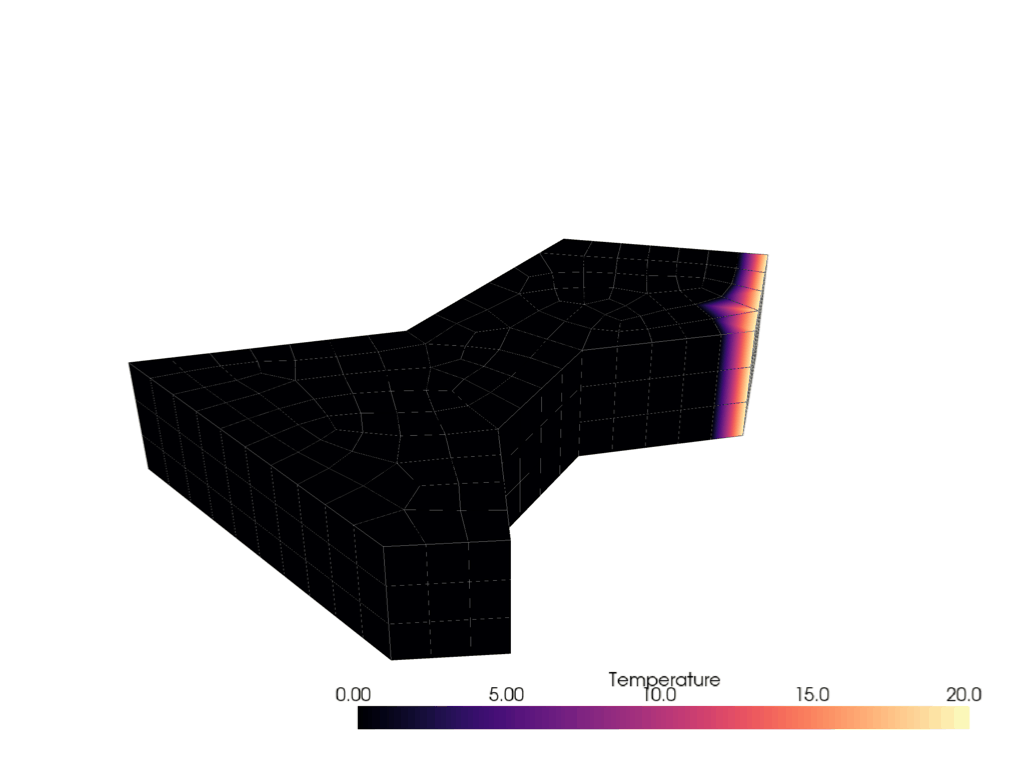

In [4]:
pl = pv.Plotter()


def animate_temp(i):
    pl.clear()
    box_heat.plot(
        node_property={"Temperature": temp[i]},
        show_undeformed=True,
        opacity=torch.linspace(0.2, 1.0, len(temp)),
        colormap="magma",
        clim=[temp.min(), temp.max()],
        plotter=pl,
        lighting=False,
    )


frames = range(len(temp))
embed_pyvista_animation(pl, animate_temp, frames)